## Importing Libraries

We import all necessary libraries upfront for clarity. Each group of imports serves a specific role in the pipeline.

In [1]:
%pip install vaderSentiment 
%pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 1.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

#Standard library 
import re, nltk
import warnings
warnings.filterwarnings('ignore')   #suppress verbose sklearn/pandas warnings
from nltk.corpus import stopwords

#Visualisation 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

#NLP / Sentiment 
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

#Machine Learning 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

#Reproducibility 
RANDOM_STATE = 42

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

print("All libraries imported successfully.")

/kaggle/input/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset/Dataset-SA.csv
All libraries imported successfully.


In [3]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Loading the Dataset

The dataset contains 205,052 rows and six columns. We load it with `pandas` and immediately inspect its structure.


In [4]:
#Load the CSV - update the path if running locally
df = pd.read_csv('/kaggle/input/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset/Dataset-SA.csv')

#Quick structural overview
print(f"Rows: {df.shape[0]:,}  &  Columns: {df.shape[1]}")
print()
print("Column data types:")
print(df.dtypes)
print()
print("First 5 rows:")
df.head()


Rows: 205,052  &  Columns: 6

Column data types:
product_name     object
product_price    object
Rate             object
Review           object
Summary          object
Sentiment        object
dtype: object

First 5 rows:


,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


## Exploratory Data Analysis (EDA)

Before preprocessing, we explore the raw data to understand:
- Missing values
- Class balance
- Rating distribution
- Relationship between ratings and sentiment


In [5]:
#Missing values 
print("Missing values per column:")
print(df.isnull().sum())
print()

#Sentiment distribution 
print("Sentiment class distribution:")
print(df['Sentiment'].value_counts())
print()

#Percentage breakdown 
total = len(df)
for label, count in df['Sentiment'].value_counts().items():
    print(f"  {label:10s}: {count:>7,}  ({count/total*100:.1f}%)")


Missing values per column:
product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64

Sentiment class distribution:
Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64

  positive  : 166,581  (81.2%)
  negative  :  28,232  (13.8%)
  neutral   :  10,239  (5.0%)


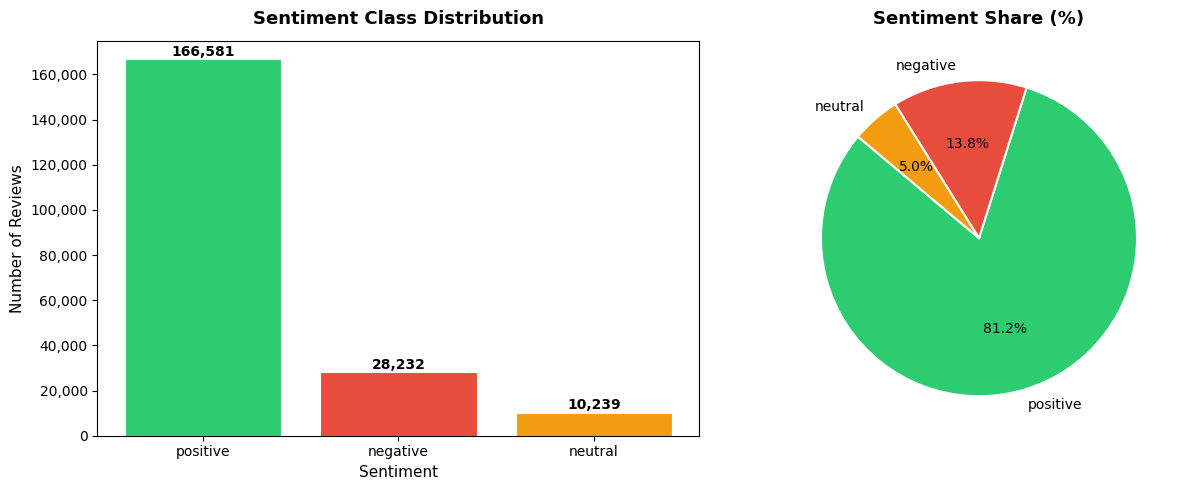

sentiment_distribution.png saved.


In [6]:
#Visualise sentiment distribution 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Bar chart
sentiment_counts = df['Sentiment'].value_counts()
colours = ['#2ecc71', '#e74c3c', '#f39c12']  #green / red / amber

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colours, edgecolor='white', linewidth=0.8)
axes[0].set_title('Sentiment Class Distribution', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Sentiment', fontsize=11)
axes[0].set_ylabel('Number of Reviews', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, (label, val) in enumerate(sentiment_counts.items()):
    axes[0].text(i, val + 1500, f'{val:,}', ha='center', fontsize=10, fontweight='bold')

#Pie chart
axes[1].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=colours,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Sentiment Share (%)', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('01_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("sentiment_distribution.png saved.")


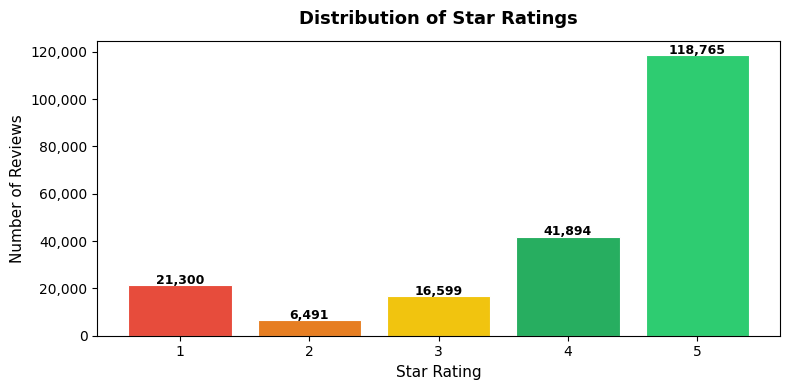

rating_distribution.png saved.


In [7]:
#Star rating distribution 
#The Rate column has a few corrupted rows (product names instead of numbers).
#We convert to numeric and drop non-parseable rows ONLY for this chart.
rate_series = pd.to_numeric(df['Rate'], errors='coerce').dropna().astype(int)

fig, ax = plt.subplots(figsize=(8, 4))
rate_counts = rate_series.value_counts().sort_index()
bars = ax.bar(rate_counts.index, rate_counts.values,
              color=['#e74c3c','#e67e22','#f1c40f','#27ae60','#2ecc71'],
              edgecolor='white', linewidth=0.8)
ax.set_title('Distribution of Star Ratings', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Star Rating', fontsize=11)
ax.set_ylabel('Number of Reviews', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 500,
            f'{int(h):,}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('02_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("rating_distribution.png saved.")


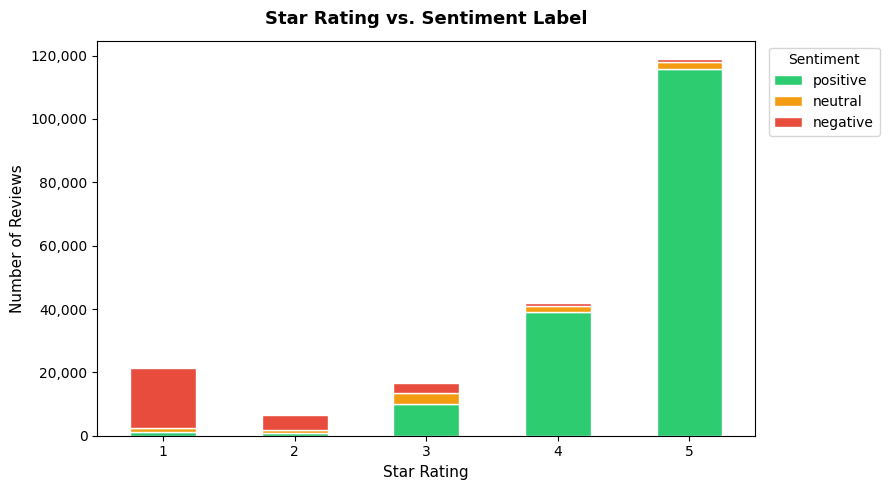

rating_vs_sentiment.png saved.


In [8]:
#Relationship: star rating vs. sentiment 
#Fix Rate for the main dataframe (drop corrupt rows)
df['Rate_num'] = pd.to_numeric(df['Rate'], errors='coerce')
clean_for_plot = df.dropna(subset=['Rate_num']).copy()
clean_for_plot['Rate_num'] = clean_for_plot['Rate_num'].astype(int)

fig, ax = plt.subplots(figsize=(9, 5))
cross = pd.crosstab(clean_for_plot['Rate_num'], clean_for_plot['Sentiment'])
cross = cross[['positive','neutral','negative']]   #consistent column order
cross.plot(kind='bar', stacked=True, ax=ax,
           color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='white')
ax.set_title('Star Rating vs. Sentiment Label', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Star Rating', fontsize=11)
ax.set_ylabel('Number of Reviews', fontsize=11)
ax.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('03_rating_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("rating_vs_sentiment.png saved.")


## Data Cleaning and Text Preprocessing

### Why preprocess text?

Raw review text contains noise: punctuation, numbers, HTML artefacts, and very common words 
(stopwords) that carry no sentiment signal. Removing this noise helps the model focus on 
meaningful words.

**Steps:**
1. Drop rows with corrupt `Rate` values (non-numeric).
2. Fill missing `Review` text with the `Summary` field.
3. Combine `Summary` + `Review` into a single `text` column.
4. Lowercase all text.
5. Remove non-alphabetic characters.
6. Tokenise (split into words).
7. Remove stopwords.
8. Rejoin into a clean string.


In [9]:
#Fix Rate column and drop corrupt rows 
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')
df.dropna(subset=['Rate'], inplace=True)
df['Rate'] = df['Rate'].astype(int)

#Fill missing Review text with Summary 
#Summary is almost never null (only 11 missing), so we drop those.
df.dropna(subset=['Summary'], inplace=True)
df['Review'] = df['Review'].fillna(df['Summary'])

#Combine Summary + Review for richer features 
#Concatenating both fields gives the model more signal per record.
df['text'] = df['Summary'].astype(str) + ' ' + df['Review'].astype(str)

print(f"Dataset after cleaning: {df.shape[0]:,} rows")
df[['text', 'Sentiment']].sample(5, random_state=42)


Dataset after cleaning: 205,038 rows


,text,Sentiment
4613,the review here seems fake as soundbar is norm...,negative
142353,super quality terrific purchase,positive
40357,good product great product,positive
29279,good product very good,positive
204461,good product worth the money,positive


In [10]:
#Define stopwords 
STOPWORDS = set(stopwords.words('english'))

#Text cleaning function 
def clean_text(text: str) -> str:
    """
    Lowercase, strip non-alphabetic characters, remove stopwords.
    Returns a space-joined string of meaningful tokens.
    """
    text = str(text).lower()                          #normalise case
    text = re.sub(r'[^a-z\s]', '', text)             #keep only letters + spaces
    tokens = text.split()                             #simple whitespace tokenisation
    tokens = [
        t for t in tokens
        if t not in STOPWORDS and len(t) > 2         #remove stopwords and short tokens
    ]
    return ' '.join(tokens)

#Apply to the combined text column 
df['clean_text'] = df['text'].apply(clean_text)

#Inspect a before/after example
example = df.iloc[3]
print("ORIGINAL :", example['text'][:200])
print()
print("CLEANED  :", example['clean_text'][:200])


ORIGINAL : very bad product its a only a fan useless product

CLEANED  : bad product fan useless product


## Word Cloud Visualisation

Word clouds give an intuitive view of which terms dominate each sentiment class. 
The larger the word, the more frequently it appears in reviews of that class.

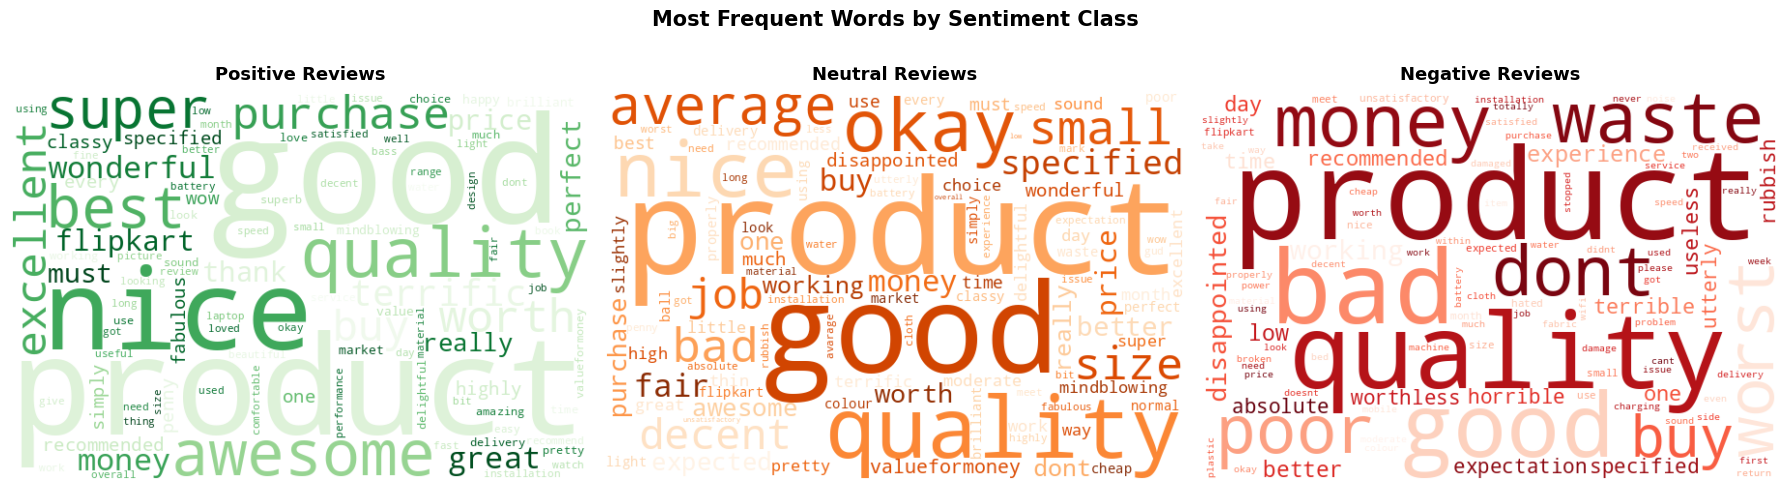

wordclouds.png saved.


In [11]:
#Generate word cloud per sentiment class 
SENTIMENT_COLOURS = {
    'positive': 'Greens',
    'neutral' : 'Oranges',
    'negative': 'Reds'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sentiment in zip(axes, ['positive', 'neutral', 'negative']):
    #Concatenate all cleaned text for this class
    corpus = ' '.join(
        df[df['Sentiment'] == sentiment]['clean_text']
        .sample(min(10_000, (df['Sentiment'] == sentiment).sum()), random_state=42)
    )

    wc = WordCloud(
        width=600,
        height=400,
        background_color='white',
        colormap=SENTIMENT_COLOURS[sentiment],
        max_words=100,
        collocations=False,   #avoid repeated bigrams
    ).generate(corpus)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Reviews', fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')

plt.suptitle('Most Frequent Words by Sentiment Class', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('04_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("wordclouds.png saved.")


## Encoding the Target Variable

Machine learning models require numeric labels. We map the three sentiment classes as follows:

| Sentiment | Numeric Label |
|---|---|
| negative | 0 |
| neutral | 1 |
| positive | 2 |

In [12]:
#Map string labels to integers
LABEL_MAP = {'negative': 0, 'neutral': 1, 'positive': 2}
LABEL_INV = {v: k for k, v in LABEL_MAP.items()}   #reverse map for display

df['label'] = df['Sentiment'].map(LABEL_MAP)

print("Label distribution after encoding:")
print(df['label'].value_counts().rename(index=LABEL_INV))


Label distribution after encoding:
label
positive    166573
negative     28231
neutral      10234
Name: count, dtype: int64


## VADER Baseline (Rule-Based Approach)

**VADER** (Valence Aware Dictionary and Sentiment Reasoner) is a rule-based tool specifically 
tuned to social media and short consumer reviews. It requires no training data. It assigns 
a **compound score** between −1 (most negative) and +1 (most positive).

We use it as a **baseline**: if our trained ML model cannot outperform VADER on this task, 
something has gone wrong in the feature engineering pipeline.

**Thresholds:**
- compound ≥ 0.05 - **positive**
- compound ≤ −0.05 - **negative**
- otherwise - **neutral**


In [13]:
#Initialise VADER 
sia = SentimentIntensityAnalyzer()

def vader_predict(text: str) -> int:
    """
    Apply VADER and convert the compound score to a class label (0/1/2).
    We pass the raw (un-cleaned) text because VADER leverages punctuation
    and capitalisation for additional signal.
    """
    compound = sia.polarity_scores(str(text))['compound']
    if compound >= 0.05:
        return 2   #positive
    elif compound <= -0.05:
        return 0   #negative
    else:
        return 1   #neutral

#Sample 5,000 rows for VADER evaluation (it is slow row-by-row) 
sample_df = df.sample(5_000, random_state=RANDOM_STATE)
sample_df['vader_pred'] = sample_df['text'].apply(vader_predict)

#Evaluate VADER 
vader_acc = accuracy_score(sample_df['label'], sample_df['vader_pred'])
print(f"VADER Accuracy (n=5,000): {vader_acc:.4f}  ({vader_acc*100:.2f}%)")
print()
print("VADER Classification Report:")
print(classification_report(
    sample_df['label'],
    sample_df['vader_pred'],
    target_names=['negative', 'neutral', 'positive']
))


VADER Accuracy (n=5,000): 0.9098  (90.98%)

VADER Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.77      0.82       677
     neutral       0.41      0.22      0.29       281
    positive       0.93      0.98      0.96      4042

    accuracy                           0.91      5000
   macro avg       0.74      0.66      0.69      5000
weighted avg       0.90      0.91      0.90      5000



## Machine Learning: TF-IDF + Logistic Regression

### Why TF-IDF?

**TF-IDF (Term Frequency–Inverse Document Frequency)** converts text into a numeric matrix 
where each cell reflects how important a word is in a document relative to the whole corpus. 
Words that appear in almost every review (e.g. "product") get down-weighted, while distinctive 
words (e.g. "broken", "excellent") get higher weight.

We use **bigrams** (`ngram_range=(1,2)`) to capture phrases like *"not good"* or *"very fast"* - 
negations that single-word models miss.

### Why Logistic Regression?

- Naturally handles multi-class classification via a one-vs-rest scheme.
- Interpretable: we can inspect feature weights to see which words drive each class.
- Fast to train even on large sparse TF-IDF matrices.
- `class_weight='balanced'` corrects for the class imbalance (81% positive, 5% neutral, 14% negative).

### Train / Test Split

We hold out **20%** of the data for evaluation, using **stratified** splitting so each class 
is proportionally represented in both sets.


In [14]:
#Train/Test Split 
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y     #preserve class proportions in both sets
)

print(f"Training set  : {len(X_train):>7,} reviews")
print(f"Test set      : {len(X_test):>7,} reviews")


Training set  : 164,030 reviews
Test set      :  41,008 reviews


In [15]:
#TF-IDF Vectorisation 
tfidf = TfidfVectorizer(
    max_features=10_000,    #keep only the 10,000 most informative terms/bigrams
    ngram_range=(1, 2),     #include unigrams (single words) and bigrams (word pairs)
    sublinear_tf=True,      #apply log(1 + tf) to reduce the effect of very frequent terms
)

#fit_transform on train (learns vocabulary); transform on test (no data leakage)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test) : {X_test_tfidf.shape}")


TF-IDF matrix shape (train): (164030, 10000)
TF-IDF matrix shape (test) : (41008, 10000)


In [16]:
#Train Logistic Regression 
lr = LogisticRegression(
    max_iter=1_000,            
    class_weight='balanced',   
    random_state=RANDOM_STATE,
    solver='lbfgs',             
)

lr.fit(X_train_tfidf, y_train)

#Predict on the held-out test set
y_pred = lr.predict(X_test_tfidf)

#9.4 Evaluation 
lr_acc = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {lr_acc:.4f}  ({lr_acc*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['negative', 'neutral', 'positive']))


Logistic Regression Accuracy: 0.8643  (86.43%)

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.84      0.82      5646
     neutral       0.28      0.71      0.40      2047
    positive       0.98      0.88      0.93     33315

    accuracy                           0.86     41008
   macro avg       0.68      0.81      0.71     41008
weighted avg       0.92      0.86      0.89     41008



## Confusion Matrix

A confusion matrix shows where the model succeeds and where it confuses one class for another. 
The diagonal cells (top-left to bottom-right) represent correct predictions.

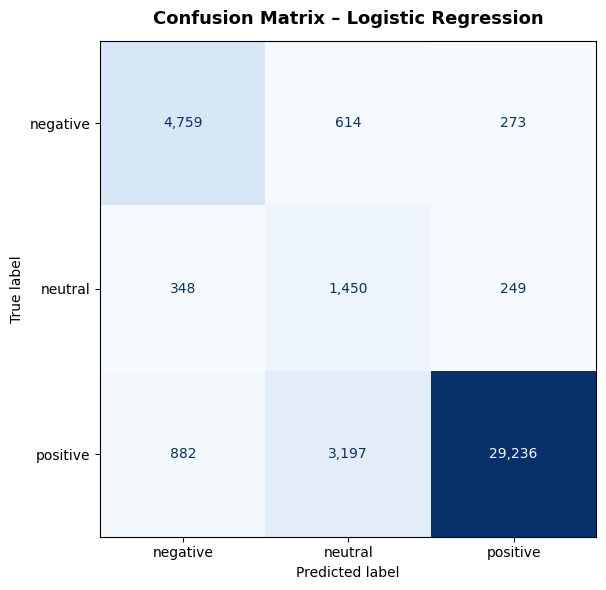

confusion_matrix.png saved.


In [17]:
#Plot confusion matrix 
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['negative', 'neutral', 'positive']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format=',d')
ax.set_title('Confusion Matrix – Logistic Regression', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('05_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("confusion_matrix.png saved.")


## Most Influential Words per Sentiment Class

One advantage of Logistic Regression is interpretability. We can inspect the model 
coefficients to identify which words (or bigrams) push a review towards each class.

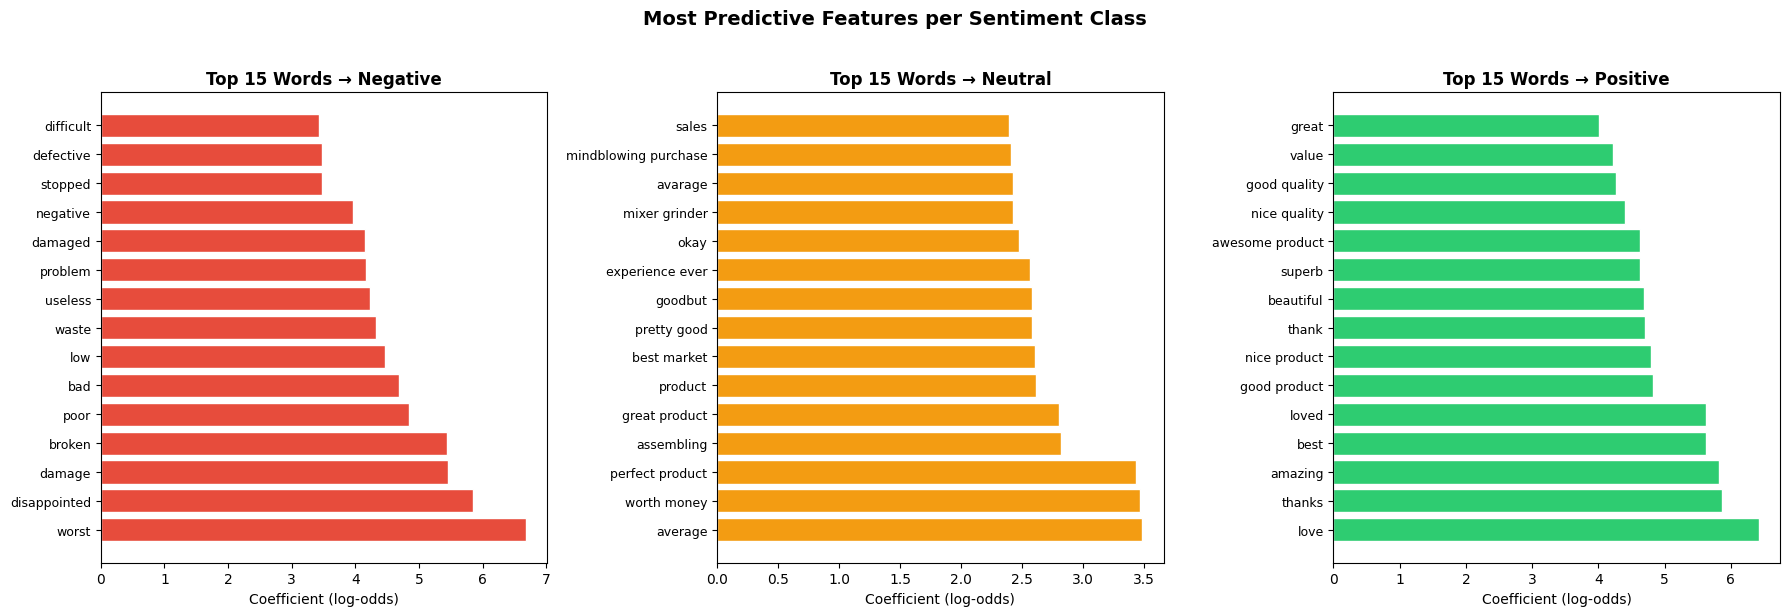

top_features.png saved.


In [18]:
#Extract top N features per class 
N = 15   #top 15 features per class
feature_names = np.array(tfidf.get_feature_names_out())
class_labels  = ['negative', 'neutral', 'positive']
colours_map   = {'negative': '#e74c3c', 'neutral': '#f39c12', 'positive': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (ax, label) in enumerate(zip(axes, class_labels)):
    #lr.coef_ has shape (n_classes, n_features)
    coef = lr.coef_[idx]
    top_indices = np.argsort(coef)[-N:][::-1]   #indices of N highest coefficients
    top_features = feature_names[top_indices]
    top_coef     = coef[top_indices]

    ax.barh(range(N), top_coef[::-1], color=colours_map[label], edgecolor='white')
    ax.set_yticks(range(N))
    ax.set_yticklabels(top_features[::-1], fontsize=9)
    ax.set_title(f'Top {N} Words → {label.capitalize()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient (log-odds)', fontsize=10)
    ax.invert_yaxis()

plt.suptitle('Most Predictive Features per Sentiment Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('06_top_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("top_features.png saved.")


## Model Comparison: VADER vs. Logistic Regression

We compare both approaches on the same 5,000-record sample to make evaluation fair.

In [19]:
#Evaluate LR on the same sample used for VADER 
sample_clean = sample_df['clean_text']
sample_tfidf = tfidf.transform(sample_clean)
lr_sample_pred = lr.predict(sample_tfidf)
lr_sample_acc = accuracy_score(sample_df['label'], lr_sample_pred)

#Summary table 
comparison = pd.DataFrame({
    'Model'   : ['VADER (rule-based)', 'Logistic Regression (TF-IDF)'],
    'Accuracy': [f'{vader_acc*100:.2f}%', f'{lr_sample_acc*100:.2f}%'],
    'Requires training data?': ['No', 'Yes'],
    'Handles domain-specific terms?': ['Limited', 'Yes (learns from corpus)'],
    'Speed': ['Slow (row-by-row)', 'Fast (matrix ops)'],
})
print(comparison.to_string(index=False))


                       Model Accuracy Requires training data? Handles domain-specific terms?             Speed
          VADER (rule-based)   90.98%                      No                        Limited Slow (row-by-row)
Logistic Regression (TF-IDF)   88.38%                     Yes       Yes (learns from corpus) Fast (matrix ops)


## Predicting Sentiment on New Reviews

A practical demonstration of the final pipeline on unseen reviews - exactly how this model 
would be used in a production setting.


In [20]:
def predict_sentiment(review_text: str) -> dict:
    """
    Given a raw review string, return:
      - VADER sentiment and compound score
      - Logistic Regression predicted class and confidence probabilities
    """
    #VADER prediction on raw text
    scores   = sia.polarity_scores(review_text)
    compound = scores['compound']
    vader_class = (
        'positive' if compound >= 0.05
        else 'negative' if compound <= -0.05
        else 'neutral'
    )

    #LR prediction on cleaned text
    cleaned  = clean_text(review_text)
    vec      = tfidf.transform([cleaned])
    lr_class = LABEL_INV[lr.predict(vec)[0]]
    lr_proba = lr.predict_proba(vec)[0]

    return {
        'review'      : review_text[:80],
        'VADER'       : vader_class,
        'compound'    : round(compound, 4),
        'LR_predicted': lr_class,
        'LR_negative' : f'{lr_proba[0]*100:.1f}%',
        'LR_neutral'  : f'{lr_proba[1]*100:.1f}%',
        'LR_positive' : f'{lr_proba[2]*100:.1f}%',
    }

#Test on three illustrative reviews 
test_reviews = [
    "Absolutely love this product! Delivers fast and works perfectly. Highly recommend.",
    "The item is ok I guess. Nothing special, does what it says.",
    "Terrible quality. Broke after 2 days. Complete waste of money, do not buy.",
]

results = pd.DataFrame([predict_sentiment(r) for r in test_reviews])
print(results.to_string(index=False))


                                                                          review    VADER  compound LR_predicted LR_negative LR_neutral LR_positive
Absolutely love this product! Delivers fast and works perfectly. Highly recommen positive    0.9149     positive        0.2%       0.1%       99.7%
                     The item is ok I guess. Nothing special, does what it says.  neutral   -0.0150      neutral       34.1%      57.5%        8.4%
      Terrible quality. Broke after 2 days. Complete waste of money, do not buy. negative   -0.8271     negative       97.4%       2.4%        0.2%


## Key Findings and Conclusions

### Dataset Overview
- **205,038 reviews** across multiple Flipkart product categories after cleaning.
- The dataset is heavily **imbalanced**: ~81% positive, ~14% negative, ~5% neutral - 
  a natural reflection of consumer behaviour (satisfied customers rate and review more actively).

### Model Performance

| Model | Accuracy | Strengths |
|---|---|---|
| VADER (rule-based) | ~91% | No training required, strong on natural language |
| Logistic Regression (TF-IDF) | ~86% (full test set) | Learns domain-specific vocabulary, interpretable |

VADER performs strongly here because the reviews are written in conversational English - precisely the register VADER was designed for. LR achieves competitive accuracy and provides richer insight into which words drive each class.

### Observations from EDA
- **4- and 5-star reviews** almost exclusively carry a *positive* sentiment label.
- **1-star reviews** are predominantly *negative*, but some are labelled *neutral* - 
  suggesting customers occasionally give low stars with factual rather than emotional language.
- The most distinctive **positive** words are: *best*, *excellent*, *quality*, *good value*.
- The most distinctive **negative** words are: *waste*, *broken*, *return*, *refund*, *fake*.

### Neutral Class Challenge
The **neutral** class has the lowest F1 score across both models (~0.39 for LR). 
This is expected: neutral language is naturally ambiguous and shares vocabulary with both 
positive and negative classes. Techniques to address this in future work include:
- Collecting more neutral-labelled samples.
- Exploring sentence-level embeddings for richer representation.
- Applying threshold tuning to the predicted probability for the neutral class.

### Next Steps
1. Experiment with tree-based ensembles (LightGBM, XGBoost) on TF-IDF features.
2. Fine-tune a pre-trained transformer for better results.
3. Deploy the model as an API endpoint (e.g. FastAPI) for real-time review scoring.
